Training Word2Vec model...
Model training complete!


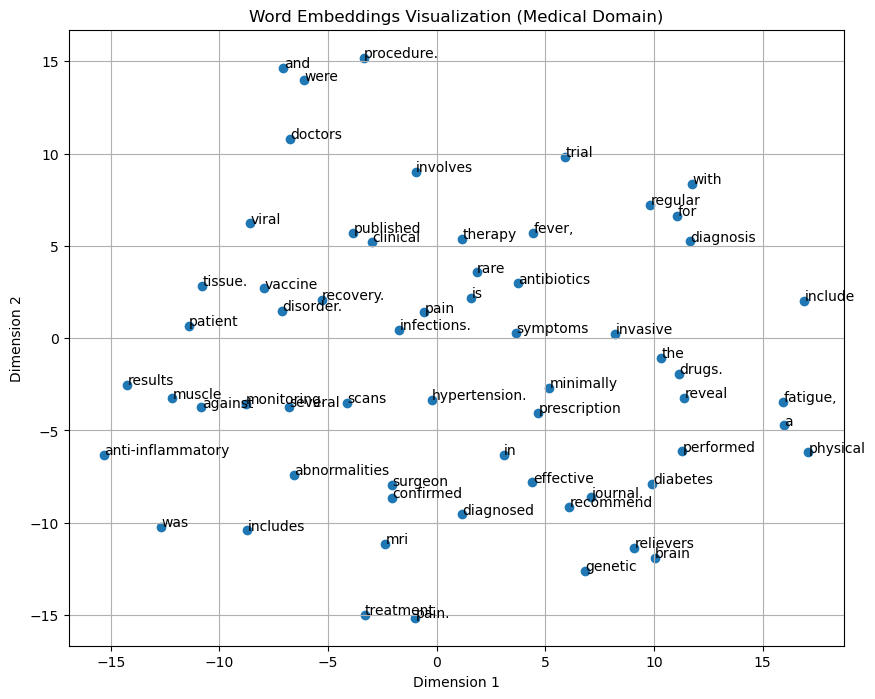

Words similar to 'treatment':
patient (0.25)
pain. (0.14)
brain (0.11)
muscle (0.11)
against (0.10)
Words similar to 'vaccine':
disorder. (0.20)
tissue. (0.14)
recovery. (0.12)
therapy (0.10)
and (0.09)


In [1]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

medical_corpus = [
 "The patient was diagnosed with diabetes and hypertension.",
 "MRI scans reveal abnormalities in the brain tissue.",
 "The treatment involves antibiotics and regular monitoring.",
 "Symptoms include fever, fatigue, and muscle pain.",
 "The vaccine is effective against several viral infections.",
 "Doctors recommend physical therapy for recovery.",
 "The clinical trial results were published in the journal.",
 "The surgeon performed a minimally invasive procedure.",
 "The prescription includes pain relievers and anti-inflammatory drugs.",
 "The diagnosis confirmed a rare genetic disorder."
]

processed_corpus = [sentence.lower().split() for sentence in medical_corpus]

print("Training Word2Vec model...")
model = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, min_count=1)
print("Model training complete!")

words = list(model.wv.index_to_key)
embeddings = np.array([model.wv[word] for word in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=5, max_iter=300)
tsne_result = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1])

for i, word in enumerate(words):
    plt.text(tsne_result[i, 0] + 0.02, tsne_result[i, 1] + 0.02, word)

plt.title("Word Embeddings Visualization (Medical Domain)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

def find_similar_words(input_word, top_n=5):
    try:
        similar_words = model.wv.most_similar(input_word, topn=top_n)
        print(f"Words similar to '{input_word}':")
        for word, similarity in similar_words:
            print(f"{word} ({similarity:.2f})")
    except KeyError:
        print(f"'{input_word}' not found in vocabulary.")

find_similar_words("treatment")
find_similar_words("vaccine")
